# Turkish Hazelnut — Basket Construction

**Goal**: Build a tradeable basket whose returns correlate with Turkish hazelnut prices.

**Data alignment**: all series use **August year-end close** (end of the Sep–Aug crop year).

---
### Basket candidates

| Column | Asset | Currency | Rationale | Role |
|---|---|---|---|---|
| `tur_usd` | iShares MSCI Turkey ETF | USD | Turkey macro + FX proxy | tradeable |
| `ulker_try` | Ülker Bisküvi (ULKER.IS) | TRY | Largest Turkish food co., direct hazelnut buyer | tradeable |
| `mdlz_usd` | Mondelēz (MDLZ) | USD | Global confectionery; hazelnut cost = input | tradeable |
| `nestle_usd` | Nestlé ADR (NSRGY) | USD | 2nd largest hazelnut buyer (after Ferrero, private) | tradeable |
| `barry_chf` | Barry Callebaut (BARN.SW) | CHF | Industrial chocolate + hazelnut paste buyer | tradeable |
| `hershey_usd` | Hershey (HSY) | USD | US confectionery, hazelnut-heavy SKUs | tradeable |
| `bunge_usd` | Bunge (BG) | USD | Agricultural commodity trader | tradeable |
| `olam_usd` | Olam Group (O32.SI → USD) | USD | Largest agri trader with documented hazelnut ops; more direct than Bunge | tradeable |
| `lindt_chf` | Lindt & Sprüngli (LISP.SW) | CHF | Premium chocolate brand; significant hazelnut paste buyer | tradeable |
| `cocoa_usd` | Cocoa futures (CC=F) | USD | Co-ingredient with hazelnuts in chocolate | tradeable |
| `dba_usd` | Invesco DB Agriculture ETF (DBA) | USD | Broad agricultural basket | tradeable |
| `tryusd` | TRY/USD spot (TRY=X) | — | TRY per 1 USD; higher = weaker lira | tradeable |
| `almond_usd` | Almond futures (ZA=F / AALM) | USD | Closest substitute nut; demand-side co-movement when hazelnuts are scarce | regression control |
| `turkey_yield` | Turkey 10Y gov't bond yield (FRED) | % | Sovereign risk; TMO support-price credibility weakens when fiscal stress rises | regression control |
| `ndvi_giresun` | NDVI Ordu/Giresun (NASA MODIS MOD13A3) | — | **Strongest leading indicator**: Apr–May crop health index for the Black Sea hazelnut belt | regression control |

In [11]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path

pd.set_option('display.float_format', '{:.3f}'.format)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

DATA = Path('../data/raw')

## 1. Load Data

In [12]:
# ── Basket asset prices (August close, crop-year end) ─────────────────────────
prices = pd.read_csv(DATA / 'basket/equity_basket_prices.csv', index_col='harvest_year')

# Original tradeable basket (extended to 12 assets in Section 1b below)
BASKET_COLS = ['tur_usd', 'ulker_try', 'mdlz_usd', 'nestle_usd',
               'barry_chf', 'hershey_usd', 'bunge_usd', 'cocoa_usd',
               'dba_usd', 'tryusd']

# Regression controls (non-tradeable; populated in Section 1b)
CONTROL_COLS: list[str] = []

# ── Hazelnut price (Giresun, USD/kg in-shell, crop-year mean Sep–Aug) ─────────
monthly = pd.read_csv(DATA / 'giresun_spot_prices_monthly.csv')
monthly = monthly[~((monthly['month'] == 8) & (monthly['period'] == 'open'))]
haz_price = (monthly.groupby('crop_year')['avg_usd_kg_inshell']
                     .mean()
                     .rename('haz_price_usd'))

# ── FAOSTAT production ────────────────────────────────────────────────────────
haz_prod = pd.read_csv(DATA / 'faostat/turkey_hazelnut_production.csv',
                       index_col='year')['production_mt'].rename('haz_prod_mt')

print('Original basket price data:')
print(prices[BASKET_COLS].notna().sum().to_frame('non-null rows').T)
print(f'\nHazelnut price: {haz_price.index.min()}–{haz_price.index.max()}, n={haz_price.notna().sum()}')
print(f'Hazelnut production: {haz_prod.index.min()}–{haz_prod.index.max()}, n={haz_prod.notna().sum()}')

Original basket price data:
               tur_usd  ulker_try  mdlz_usd  nestle_usd  barry_chf  \
non-null rows       17         21        24          25         25   

               hershey_usd  bunge_usd  cocoa_usd  dba_usd  tryusd  
non-null rows           25         24         22       18      20  

Hazelnut price: 2000–2024, n=23
Hazelnut production: 1961–2024, n=64


## 1b. Supplementary Features

Fetch **Olam Group** (SGX: O32.SI → USD) and **Lindt & Sprüngli** (SIX: LISP.SW) via yfinance and merge with the existing basket.  
Add three regression **control variables** that are not priceable but are strong explanatory signals:

- **Almond futures** (CME: ZA=F) — closest substitute nut; demand-side co-movement  
- **Turkey 10Y yield** (FRED: IRLTLT01TRM156N) — sovereign risk proxy; TMO support-price credibility  
- **NDVI Ordu/Giresun** (NASA MODIS MOD13A3, Apr–May) — pre-bloom crop health; strongest leading indicator available

In [13]:
# ── Supplementary data: Olam, Lindt, Almond proxy, Turkey yield, NDVI ─────────
# Fetches new market data and merges into `prices`.
# Then redefines BASKET_COLS (12 tradeable assets) and CONTROL_COLS.

try:
    import yfinance as yf
    _HAS_YF = True
except ImportError:
    _HAS_YF = False
    print('WARNING: yfinance not found — run: pip install yfinance')


def _last_aug_close(df: pd.DataFrame) -> pd.DataFrame:
    """Return last trading day of August keyed by harvest year (= calendar year of Aug close)."""
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    aug = df[df.index.month == 8]
    out = aug.groupby(aug.index.year).last()
    out.index.name = 'harvest_year'
    return out


# ── 1. Market data (yfinance): Olam Group, Lindt, Almond futures ──────────────
# Olam Group (SGX: O32.SI) is denominated in SGD — convert to USD via SGDUSD=X.
# Lindt & Sprüngli (SIX: LISP.SW) is in CHF (same currency as Barry Callebaut).
# Almond futures (CME: ZA=F) — thin liquidity; kept as regression control only.

if _HAS_YF:
    try:
        _tickers = ['O32.SI', 'LISP.SW', 'ZA=F', 'SGDUSD=X']
        _raw = yf.download(_tickers, start='1999-01-01', end='2025-09-01',
                           auto_adjust=True, progress=False)
        _close = _raw['Close'] if isinstance(_raw.columns, pd.MultiIndex) else _raw
        _aug = _last_aug_close(_close)

        # Olam SGD → USD
        if 'O32.SI' in _aug.columns and 'SGDUSD=X' in _aug.columns:
            prices['olam_usd'] = (_aug['O32.SI'] * _aug['SGDUSD=X']).reindex(prices.index)
        else:
            prices['olam_usd'] = np.nan

        # Lindt CHF (matches barry_chf currency)
        prices['lindt_chf'] = _aug.get('LISP.SW', pd.Series(dtype=float)).reindex(prices.index)

        # Almond proxy — control only
        _alm = _aug.get('ZA=F', pd.Series(dtype=float)).reindex(prices.index)
        prices['almond_usd'] = _alm if _alm.notna().sum() >= 5 else np.nan

    except Exception as _e:
        print(f'yfinance error: {_e}')
        for _c in ['olam_usd', 'lindt_chf', 'almond_usd']:
            prices[_c] = np.nan
else:
    for _c in ['olam_usd', 'lindt_chf', 'almond_usd']:
        prices[_c] = np.nan

for _col in ['olam_usd', 'lindt_chf', 'almond_usd']:
    n = prices[_col].notna().sum()
    print(f'{_col:<22} {"" if n == 0 else f"{n} non-null years"}'
          f'{"no data" if n == 0 else ""}')


# ── 2. Turkey 10Y government bond yield (FRED: IRLTLT01TRM156N) ──────────────
# Rationale: rising sovereign risk weakens TMO's ability to defend the hazelnut
# support price, so yield spikes tend to coincide with TRY/hazelnut decoupling.
_YIELD_PATH = DATA / 'basket/turkey_yield.csv'

if _YIELD_PATH.exists():
    _ty = pd.read_csv(_YIELD_PATH, index_col=0, parse_dates=True)
    prices['turkey_yield'] = _last_aug_close(_ty).iloc[:, 0].reindex(prices.index)
else:
    try:
        import pandas_datareader.data as web
        _ty_raw = web.DataReader('IRLTLT01TRM156N', 'fred', '1999-01-01', '2025-09-01')
        prices['turkey_yield'] = _last_aug_close(_ty_raw).iloc[:, 0].reindex(prices.index)
        _ty_raw.to_csv(_YIELD_PATH)
    except Exception as _e:
        prices['turkey_yield'] = np.nan
        print(f'turkey_yield: FRED fetch failed ({_e}); set to NaN')

n = prices['turkey_yield'].notna().sum()
print(f'{"turkey_yield":<22} {"no data" if n == 0 else f"{n} non-null years"}')


# ── 3. NDVI Ordu/Giresun — NASA MODIS MOD13A3 (April–May average) ─────────────
# Pre-bloom NDVI is the strongest known leading indicator of hazelnut yield.
#
# bbox covers the Samsun–Ordu–Giresun–Trabzon hazelnut corridor:
#   lon 35.0°–40.5°E,  lat 40.1°–41.5°N
# This captures the four core Black Sea hazelnut provinces. The western bound
# at 35.0°E includes Samsun (Turkey's 3rd-largest producer at ~35.8°–37.4°E)
# without pulling in unrelated interior Anatolia.
#
# To generate ndvi_giresun.csv:
#   1. Register (free) at https://urs.earthdata.nasa.gov
#   2. Submit AppEEARS task: product MOD13A3.061, Apr–May months, 2000–present,
#      bbox: lon 35.0–40.5, lat 40.1–41.5; download the per-pixel CSV.
#   3. Average `_1_km_monthly_NDVI` over the bbox for each year's Apr–May.
#   4. Save as data/raw/basket/ndvi_giresun.csv with columns: year, ndvi_mean
#      (year = harvest year; Apr–May of year t predicts crop year t yield).

_NDVI_PATH = DATA / 'basket/ndvi_giresun.csv'
if _NDVI_PATH.exists():
    _ndvi = pd.read_csv(_NDVI_PATH, index_col='year')['ndvi_mean']
    prices['ndvi_giresun'] = _ndvi.reindex(prices.index)
    n = prices['ndvi_giresun'].notna().sum()
    print(f'{"ndvi_giresun":<22} {n} non-null years')
else:
    prices['ndvi_giresun'] = np.nan
    print('ndvi_giresun           not found — see AppEEARS instructions above')


# ── Update BASKET_COLS and CONTROL_COLS ────────────────────────────────────────
BASKET_COLS = [
    'tur_usd', 'ulker_try', 'mdlz_usd', 'nestle_usd',
    'barry_chf', 'hershey_usd', 'bunge_usd', 'cocoa_usd',
    'dba_usd', 'tryusd',
    'olam_usd', 'lindt_chf',          # new: Olam, Lindt
]
CONTROL_COLS = [
    c for c in ['almond_usd', 'turkey_yield', 'ndvi_giresun']
    if prices[c].notna().sum() >= 5
]

print(f'\nTradeable basket   ({len(BASKET_COLS)}): {BASKET_COLS}')
print(f'Regression controls ({len(CONTROL_COLS)}): {CONTROL_COLS}')
print('\nNon-null rows — all features:')
_all = BASKET_COLS + CONTROL_COLS
print(prices[_all].notna().sum().to_frame('non-null rows').T.to_string())

HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ZA=F"}}}
$O32.SI: possibly delisted; no timezone found
$ZA=F: possibly delisted; no timezone found

2 Failed downloads:
['O32.SI', 'ZA=F']: possibly delisted; no timezone found


olam_usd               no data
lindt_chf              25 non-null years
almond_usd             no data
turkey_yield: FRED fetch failed (No module named 'pandas_datareader'); set to NaN
turkey_yield           no data
ndvi_giresun           not found — see AppEEARS instructions above

Tradeable basket   (12): ['tur_usd', 'ulker_try', 'mdlz_usd', 'nestle_usd', 'barry_chf', 'hershey_usd', 'bunge_usd', 'cocoa_usd', 'dba_usd', 'tryusd', 'olam_usd', 'lindt_chf']
Regression controls (0): []

Non-null rows — all features:
               tur_usd  ulker_try  mdlz_usd  nestle_usd  barry_chf  hershey_usd  bunge_usd  cocoa_usd  dba_usd  tryusd  olam_usd  lindt_chf
non-null rows       17         21        24          25         25           25         24         22       18      20         0         25


## 2. Annual Returns

Convert price levels to annual returns. All basket analysis is on returns — comparable across currencies and scales.

In [14]:
ALL_FEATURES = BASKET_COLS + CONTROL_COLS

rets = prices[ALL_FEATURES].pct_change(fill_method=None)

# Hazelnut targets
rets['haz_price_ret'] = haz_price.pct_change(fill_method=None)
rets['haz_prod_ret']  = haz_prod.pct_change(fill_method=None)

print('Annual returns — sample tail (tradeable basket):')
rets[BASKET_COLS + ['haz_price_ret', 'haz_prod_ret']].tail(12).round(3)

Annual returns — sample tail (tradeable basket):


,tur_usd,ulker_try,mdlz_usd,nestle_usd,barry_chf,hershey_usd,bunge_usd,cocoa_usd,dba_usd,tryusd,olam_usd,lindt_chf,haz_price_ret,haz_prod_ret
harvest_year,,,,,,,,,,,,,,
2013,-0.114,0.320,0.137,0.083,-0.020,0.307,0.209,-0.091,-0.176,0.116,NaN,0.270,0.282,-0.168
2014,0.164,0.549,0.199,0.224,0.302,0.014,0.134,0.334,0.055,0.060,NaN,0.314,0.868,-0.180
2015,-0.294,0.134,0.190,-0.022,-0.042,0.001,-0.131,-0.036,-0.211,0.351,NaN,0.150,-0.398,0.436
2016,0.015,0.179,0.080,0.113,0.208,0.145,-0.096,-0.058,-0.031,0.016,NaN,0.057,-0.041,-0.350
2017,0.250,0.002,-0.081,0.099,0.095,0.075,0.197,-0.327,-0.079,0.166,NaN,-0.019,-0.250,0.607
2018,-0.548,-0.276,0.073,0.021,0.261,-0.017,-0.107,0.182,-0.085,0.949,NaN,0.331,-0.117,-0.237
2019,0.230,0.224,0.322,0.342,0.189,0.618,-0.149,-0.070,-0.113,-0.134,NaN,0.030,0.301,0.507
2020,-0.157,0.287,0.081,0.099,0.000,-0.042,-0.109,0.260,-0.001,0.256,NaN,0.074,-0.015,-0.143
2021,0.232,-0.129,0.085,0.077,0.179,0.221,0.712,NaN,0.298,0.142,NaN,0.418,-0.177,0.029


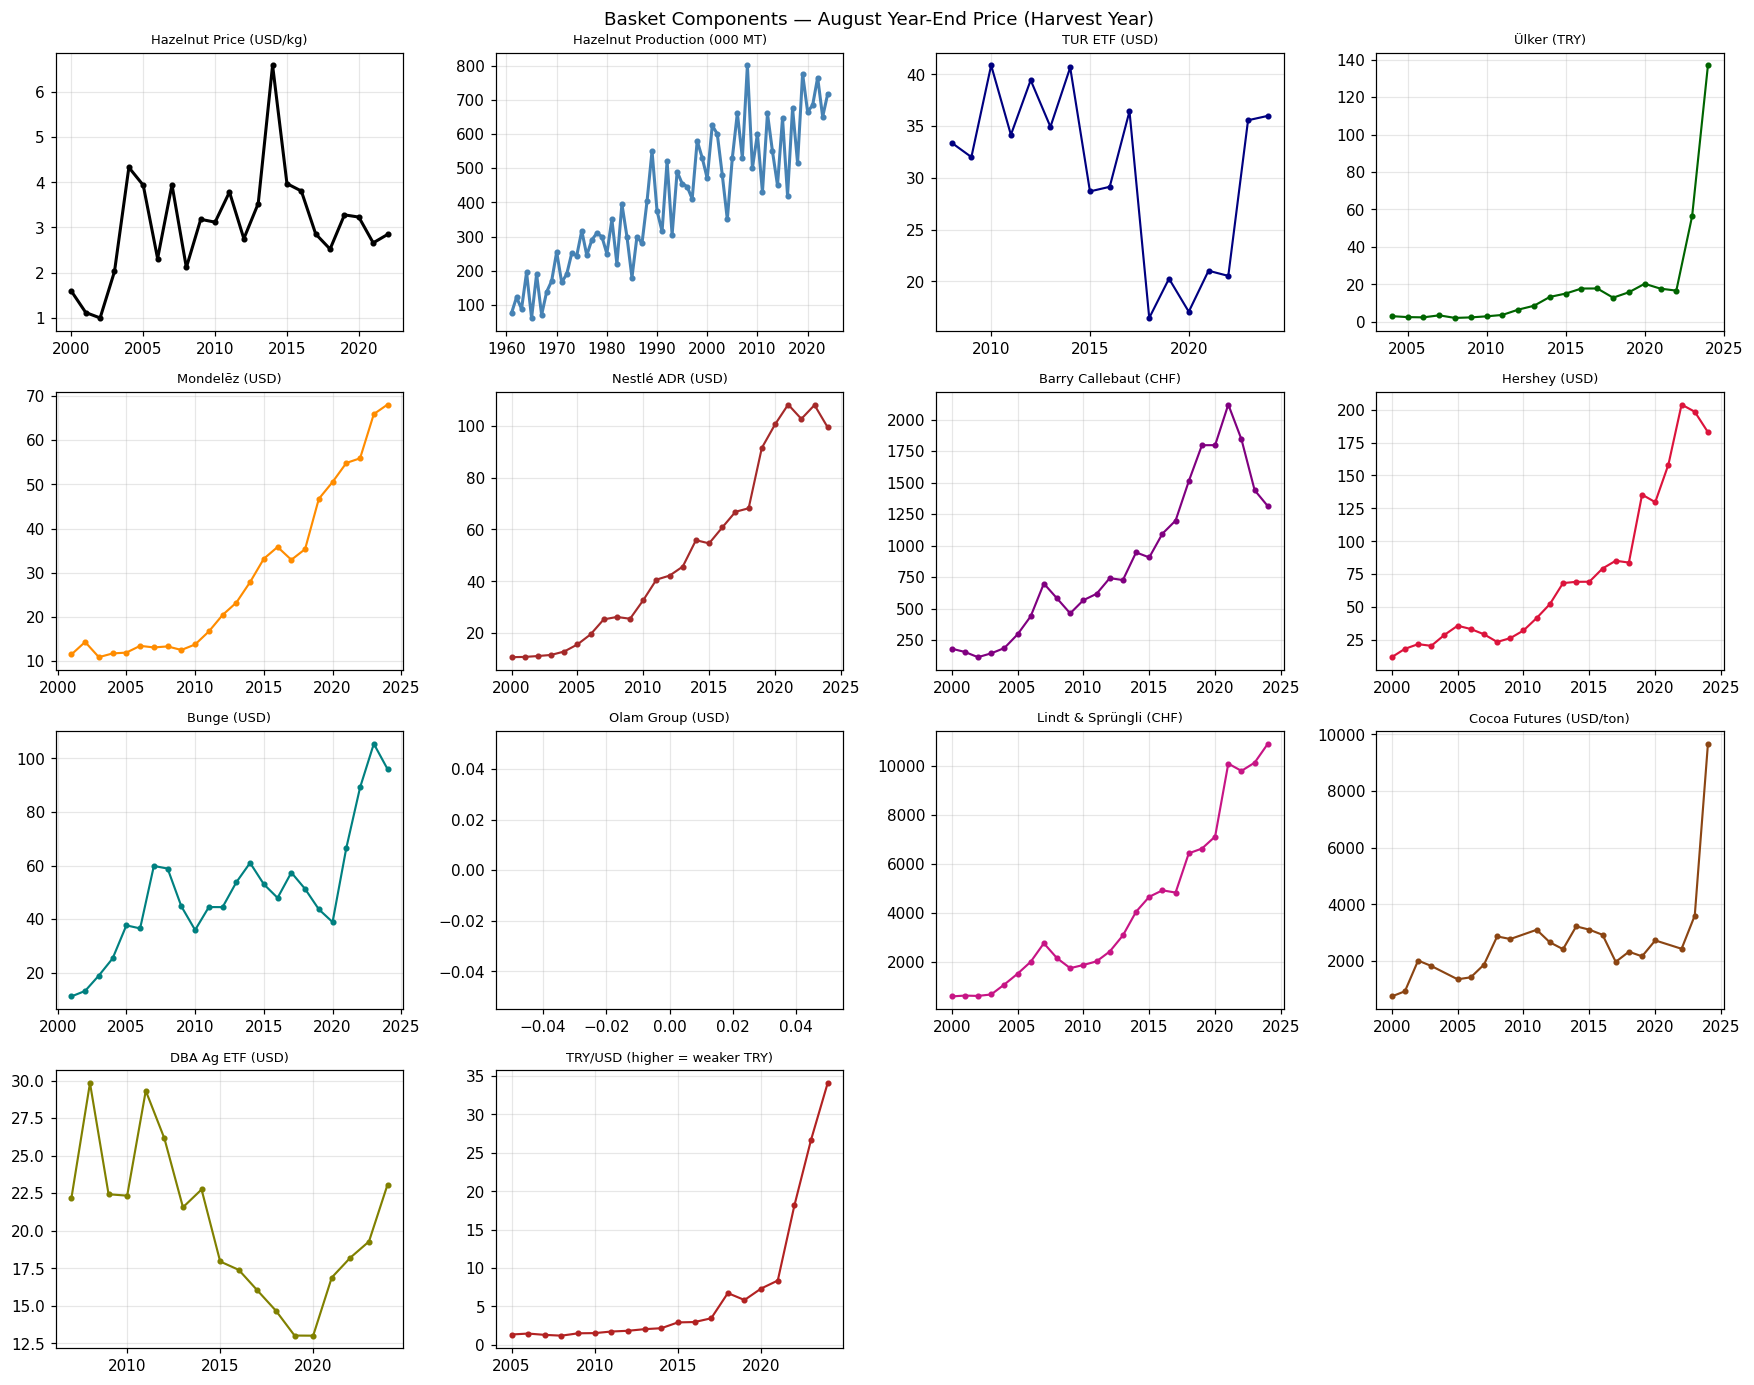

In [15]:
# ── Price level time series ────────────────────────────────────────────────────
plot_series = [
    ('haz_price_usd', haz_price,              'Hazelnut Price (USD/kg)',        'black',            True),
    ('haz_prod_mt',   haz_prod / 1e3,         'Hazelnut Production (000 MT)',   'steelblue',        True),
    ('tur_usd',       prices['tur_usd'],       'TUR ETF (USD)',                  'navy',             False),
    ('ulker_try',     prices['ulker_try'],     'Ülker (TRY)',                    'darkgreen',        False),
    ('mdlz_usd',      prices['mdlz_usd'],      'Mondelēz (USD)',                 'darkorange',       False),
    ('nestle_usd',    prices['nestle_usd'],    'Nestlé ADR (USD)',               'brown',            False),
    ('barry_chf',     prices['barry_chf'],     'Barry Callebaut (CHF)',          'purple',           False),
    ('hershey_usd',   prices['hershey_usd'],   'Hershey (USD)',                  'crimson',          False),
    ('bunge_usd',     prices['bunge_usd'],     'Bunge (USD)',                    'teal',             False),
    ('olam_usd',      prices['olam_usd'],      'Olam Group (USD)',               'forestgreen',      False),
    ('lindt_chf',     prices['lindt_chf'],     'Lindt & Sprüngli (CHF)',         'mediumvioletred',  False),
    ('cocoa_usd',     prices['cocoa_usd'],     'Cocoa Futures (USD/ton)',        'saddlebrown',      False),
    ('dba_usd',       prices['dba_usd'],       'DBA Ag ETF (USD)',               'olive',            False),
    ('tryusd',        prices['tryusd'],        'TRY/USD (higher = weaker TRY)', 'firebrick',        False),
]

# Append available control variables
_ctrl_meta = {
    'almond_usd':   ('Almond Futures (USD) [ctrl]',      'goldenrod'),
    'turkey_yield': ('Turkey 10Y Yield (%) [ctrl]',      'darkcyan'),
    'ndvi_giresun': ('NDVI Giresun Apr–May [ctrl]',      'limegreen'),
}
for col, (label, color) in _ctrl_meta.items():
    if col in prices.columns and prices[col].notna().sum() > 0:
        plot_series.append((col, prices[col], label, color, False))

n_plots = len(plot_series)
n_cols  = 4
n_rows  = (n_plots + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.2))
axes = axes.flatten()

for ax, (_, s, label, color, bold) in zip(axes, plot_series):
    s = s.dropna()
    lw = 2.0 if bold else 1.4
    ax.plot(s.index, s.values, color=color, lw=lw, marker='o', ms=3)
    ax.set_title(label, fontsize=8.5)
    ax.grid(alpha=0.3)

for ax in axes[n_plots:]:
    ax.set_visible(False)

plt.suptitle('Basket Components — August Year-End Price (Harvest Year)', fontsize=12)
plt.tight_layout()
plt.show()

## 3. Correlation with Hazelnut Price & Production

In [16]:
# Correlation of each feature's return with hazelnut price & production returns
corr_df = rets[ALL_FEATURES + ['haz_price_ret', 'haz_prod_ret']].dropna(how='all')

corr_price = corr_df[ALL_FEATURES].corrwith(corr_df['haz_price_ret']).rename('r_vs_price')
corr_prod  = corr_df[ALL_FEATURES].corrwith(corr_df['haz_prod_ret']).rename('r_vs_production')

summary = pd.concat([corr_price, corr_prod], axis=1)
summary['n_overlap_price'] = [corr_df[[c, 'haz_price_ret']].dropna().shape[0] for c in ALL_FEATURES]
summary['n_overlap_prod']  = [corr_df[[c, 'haz_prod_ret']].dropna().shape[0] for c in ALL_FEATURES]
summary['role'] = ['control' if c in CONTROL_COLS else 'tradeable' for c in ALL_FEATURES]
summary = summary.sort_values('r_vs_price', ascending=False)

print('Correlation of annual returns vs hazelnut price / production:')
print(summary.round(3).to_string())

Correlation of annual returns vs hazelnut price / production:
             r_vs_price  r_vs_production  n_overlap_price  n_overlap_prod       role
ulker_try         0.515           -0.207               18              20  tradeable
bunge_usd         0.324           -0.115               21              23  tradeable
lindt_chf         0.315           -0.166               22              24  tradeable
barry_chf         0.279            0.024               22              24  tradeable
nestle_usd        0.224            0.049               22              24  tradeable
tur_usd           0.145            0.239               14              16  tradeable
hershey_usd       0.071            0.151               22              24  tradeable
cocoa_usd        -0.074           -0.120               16              18  tradeable
tryusd           -0.134           -0.190               17              19  tradeable
dba_usd          -0.170           -0.014               15              17  tradeable
mdl

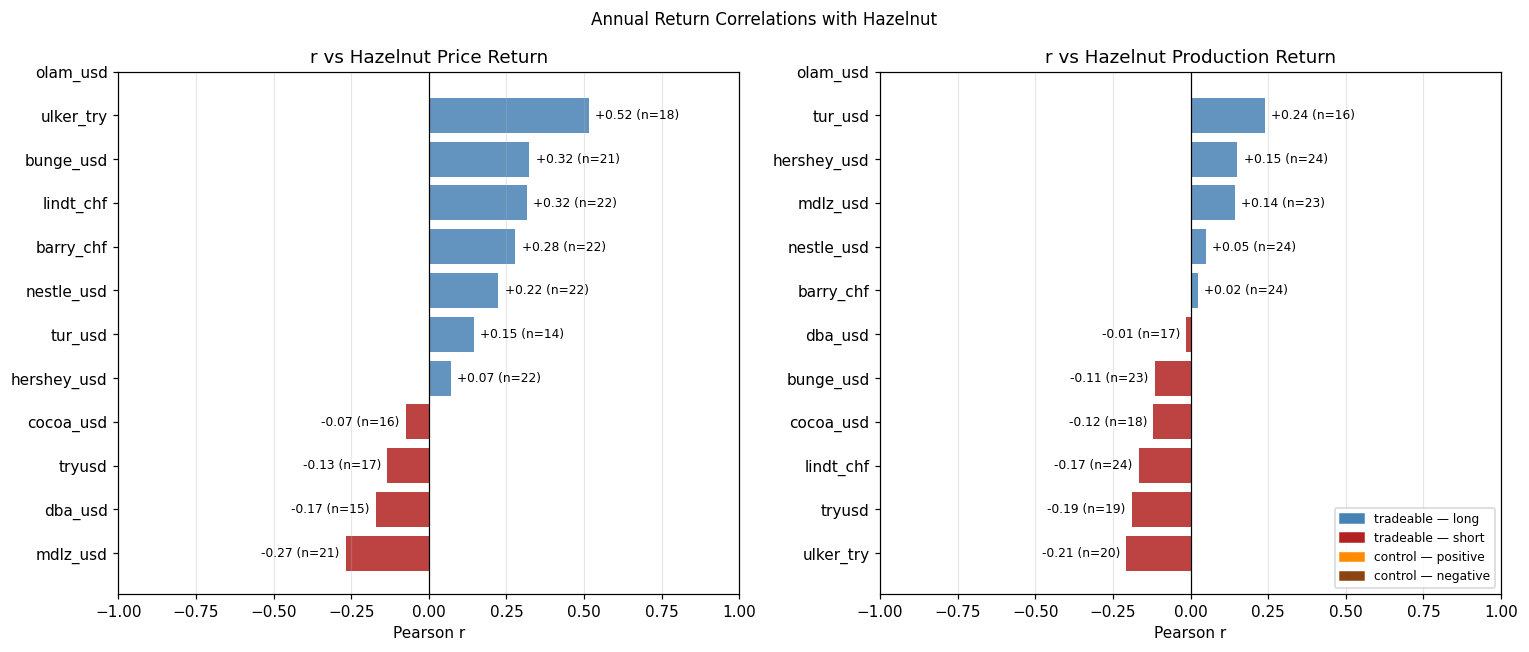

In [17]:
# ── Correlation bar chart — tradeable (blue/red) vs controls (orange/brown) ───
from matplotlib.patches import Patch

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, max(6, len(ALL_FEATURES) * 0.45)))

n_col_map = {'r_vs_price': 'n_overlap_price', 'r_vs_production': 'n_overlap_prod'}

def _bar_color(idx, val):
    if summary.loc[idx, 'role'] == 'control':
        return 'darkorange' if val >= 0 else 'saddlebrown'
    return 'steelblue' if val >= 0 else 'firebrick'

for ax, col, title in [
    (ax1, 'r_vs_price',      'r vs Hazelnut Price Return'),
    (ax2, 'r_vs_production', 'r vs Hazelnut Production Return'),
]:
    vals  = summary[col].sort_values()
    n_col = n_col_map[col]
    colors = [_bar_color(idx, v) for idx, v in vals.items()]

    ax.barh(range(len(vals)), vals.values, color=colors, alpha=0.85)
    ax.set_yticks(range(len(vals)))
    ax.set_yticklabels(vals.index)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlim(-1, 1)
    ax.set_xlabel('Pearson r')
    ax.set_title(title)
    ax.grid(axis='x', alpha=0.3)
    for j, (idx, v) in enumerate(vals.items()):
        n = summary.loc[idx, n_col]
        ax.text(v + (0.02 if v >= 0 else -0.02), j, f'{v:+.2f} (n={n})',
                va='center', ha='left' if v >= 0 else 'right', fontsize=8)

legend_handles = [
    Patch(color='steelblue',   label='tradeable — long'),
    Patch(color='firebrick',   label='tradeable — short'),
    Patch(color='darkorange',  label='control — positive'),
    Patch(color='saddlebrown', label='control — negative'),
]
ax2.legend(handles=legend_handles, loc='lower right', fontsize=8)

plt.suptitle('Annual Return Correlations with Hazelnut', fontsize=11)
plt.tight_layout()
plt.show()

## 4. Two-Stage Basket Construction

**Model A — Tradeable basket only** (`BASKET_COLS`): these weights define the priceable product.  
**Model B — Full model** (`BASKET_COLS + CONTROL_COLS`): adds NDVI, Turkey yield, almond futures as regression controls to measure total explanatory power and validate the basket design.

Controls are never included in the priceable basket — they improve in-sample fit and flag which tradeable assets carry genuine hazelnut signal vs. noise.

In [18]:
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler

labels = {
    'tur_usd':      'TUR ETF',
    'ulker_try':    'Ülker (TRY)',
    'mdlz_usd':     'Mondelēz',
    'nestle_usd':   'Nestlé ADR',
    'barry_chf':    'Barry Callebaut',
    'hershey_usd':  'Hershey',
    'bunge_usd':    'Bunge',
    'cocoa_usd':    'Cocoa futures',
    'dba_usd':      'DBA Ag ETF',
    'tryusd':       'TRY/USD (spot)',
    'olam_usd':     'Olam Group (USD)',
    'lindt_chf':    'Lindt & Sprüngli',
    'almond_usd':   'Almond futures',
    'turkey_yield': 'Turkey 10Y yield',
    'ndvi_giresun': 'NDVI Giresun',
}

MIN_OBS = 10
alphas  = np.logspace(-2, 3, 100)

def _fit_ridge(feature_cols, tag):
    reg = rets[feature_cols + ['haz_price_ret']].dropna()
    if len(reg) < MIN_OBS:
        print(f'{tag}: n={len(reg)} < {MIN_OBS} — skipped')
        return None, reg, None
    X = StandardScaler().fit_transform(reg[feature_cols].values)
    y = reg['haz_price_ret'].values
    m = RidgeCV(alphas=alphas, cv=None, scoring='r2').fit(X, y)
    y_hat = m.predict(X)
    r2 = 1 - np.sum((y - y_hat) ** 2) / np.sum((y - y.mean()) ** 2)
    r  = np.corrcoef(y, y_hat)[0, 1]
    print(f'{tag}:  n={len(reg)},  alpha={m.alpha_:.2f},  R²={r2:.3f},  r={r:.3f}')
    return m, reg, pd.Series(y_hat, index=reg.index, name='basket_ret')

usable_basket   = [c for c in BASKET_COLS  if rets[[c, 'haz_price_ret']].dropna().shape[0] >= MIN_OBS]
usable_controls = [c for c in CONTROL_COLS if rets[[c, 'haz_price_ret']].dropna().shape[0] >= MIN_OBS]
usable_all      = usable_basket + usable_controls

print(f'Tradeable features  ({len(usable_basket)}): {usable_basket}')
print(f'Control features    ({len(usable_controls)}): {usable_controls}\n')

ridge_b, reg_b, basket_ret_b = _fit_ridge(usable_basket, 'Model A (basket only)')
ridge_f, reg_f, basket_ret_f = _fit_ridge(usable_all,    'Model B (basket+ctrl)')

# Canonical basket return = tradeable model; fall back to empty series
basket_ret = basket_ret_b if basket_ret_b is not None else pd.Series(dtype=float, name='basket_ret')

# ── Print weights ──────────────────────────────────────────────────────────────
for model, features, tag in [
    (ridge_b, usable_basket, 'MODEL A — TRADEABLE BASKET'),
    (ridge_f, usable_all,    'MODEL B — BASKET + CONTROLS'),
]:
    if model is None:
        continue
    print(f'\n── {tag} ──')
    print(f'{"Asset":<25} {"Std coef":>10}   Dir    Role')
    print('─' * 58)
    for col, sc in sorted(zip(features, model.coef_), key=lambda x: -abs(x[1])):
        role = 'control' if col in CONTROL_COLS else 'tradeable'
        print(f'{labels.get(col, col):<25} {sc:>+10.4f}   {"LONG " if sc > 0 else "SHORT"}  {role}')

Tradeable features  (11): ['tur_usd', 'ulker_try', 'mdlz_usd', 'nestle_usd', 'barry_chf', 'hershey_usd', 'bunge_usd', 'cocoa_usd', 'dba_usd', 'tryusd', 'lindt_chf']
Control features    (0): []

Model A (basket only):  n=10,  alpha=1000.00,  R²=0.015,  r=0.548
Model B (basket+ctrl):  n=10,  alpha=1000.00,  R²=0.015,  r=0.548

── MODEL A — TRADEABLE BASKET ──
Asset                       Std coef   Dir    Role
──────────────────────────────────────────────────────────
Cocoa futures                +0.0018   LONG   tradeable
Nestlé ADR                   +0.0017   LONG   tradeable
TRY/USD (spot)               -0.0011   SHORT  tradeable
TUR ETF                      +0.0011   LONG   tradeable
Ülker (TRY)                  +0.0009   LONG   tradeable
DBA Ag ETF                   +0.0007   LONG   tradeable
Hershey                      +0.0006   LONG   tradeable
Mondelēz                     +0.0004   LONG   tradeable
Bunge                        +0.0004   LONG   tradeable
Barry Callebaut           

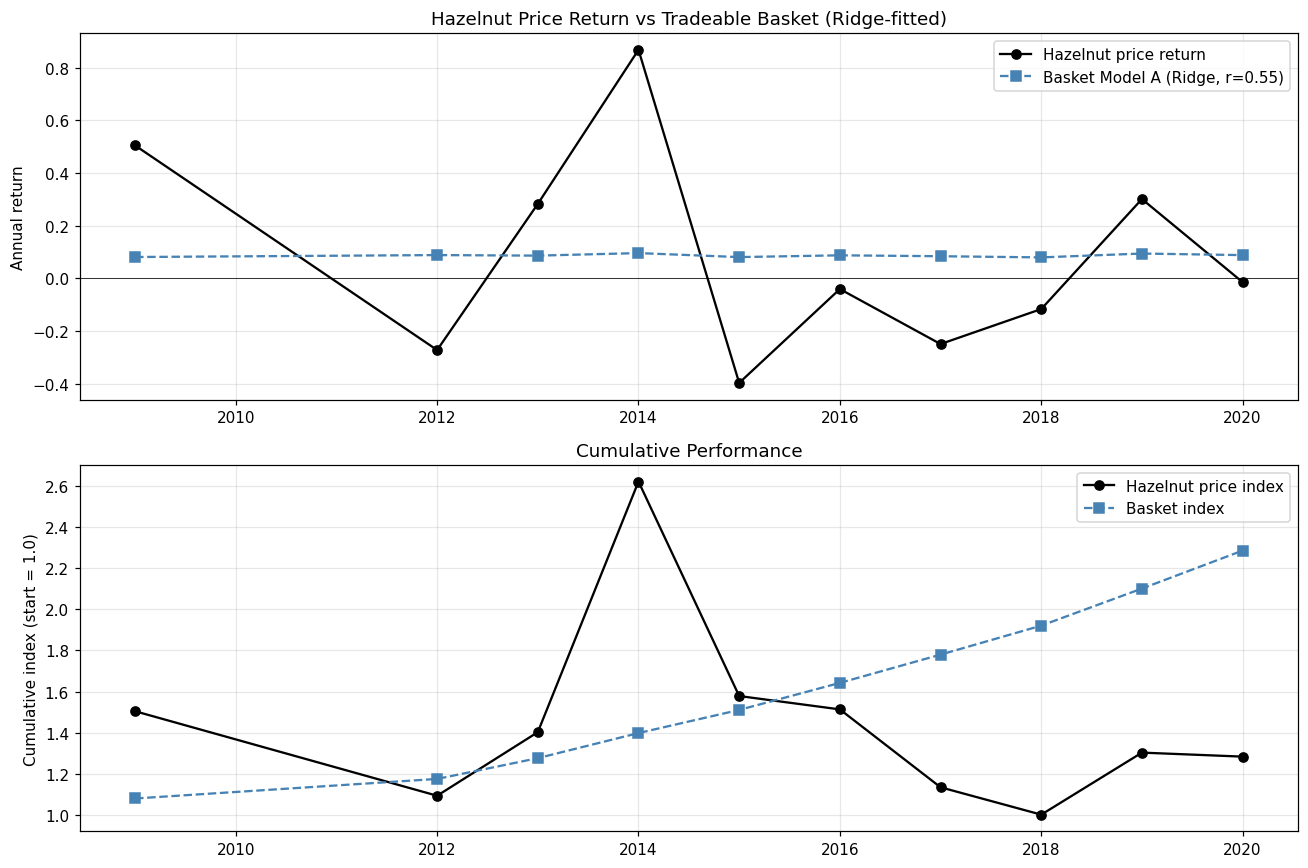

In [19]:
# ── Basket vs hazelnut price: returns and cumulative index ────────────────────
def cumulative_index(ret_series):
    return (1 + ret_series).cumprod()

if len(basket_ret) == 0:
    print('No basket return computed — insufficient data overlap.')
else:
    _reg = rets[usable_basket + ['haz_price_ret']].dropna()
    _haz = _reg['haz_price_ret']
    _bkt = basket_ret.reindex(_reg.index).dropna()
    _r   = np.corrcoef(_haz.values, _bkt.values)[0, 1]

    haz_idx    = cumulative_index(_haz)
    basket_idx = cumulative_index(_bkt)

    fig, axes = plt.subplots(2, 1, figsize=(12, 8))

    axes[0].plot(_reg.index, _haz, 'o-', color='black', lw=1.5, label='Hazelnut price return')
    axes[0].plot(_bkt.index, _bkt.values, 's--', color='steelblue',
                 lw=1.5, label=f'Basket Model A (Ridge, r={_r:.2f})')
    axes[0].axhline(0, color='black', lw=0.5)
    axes[0].set_ylabel('Annual return')
    axes[0].set_title('Hazelnut Price Return vs Tradeable Basket (Ridge-fitted)')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(haz_idx.index, haz_idx.values, 'o-', color='black', lw=1.5, label='Hazelnut price index')
    axes[1].plot(basket_idx.index, basket_idx.values, 's--', color='steelblue', lw=1.5, label='Basket index')
    axes[1].set_ylabel('Cumulative index (start = 1.0)')
    axes[1].set_title('Cumulative Performance')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

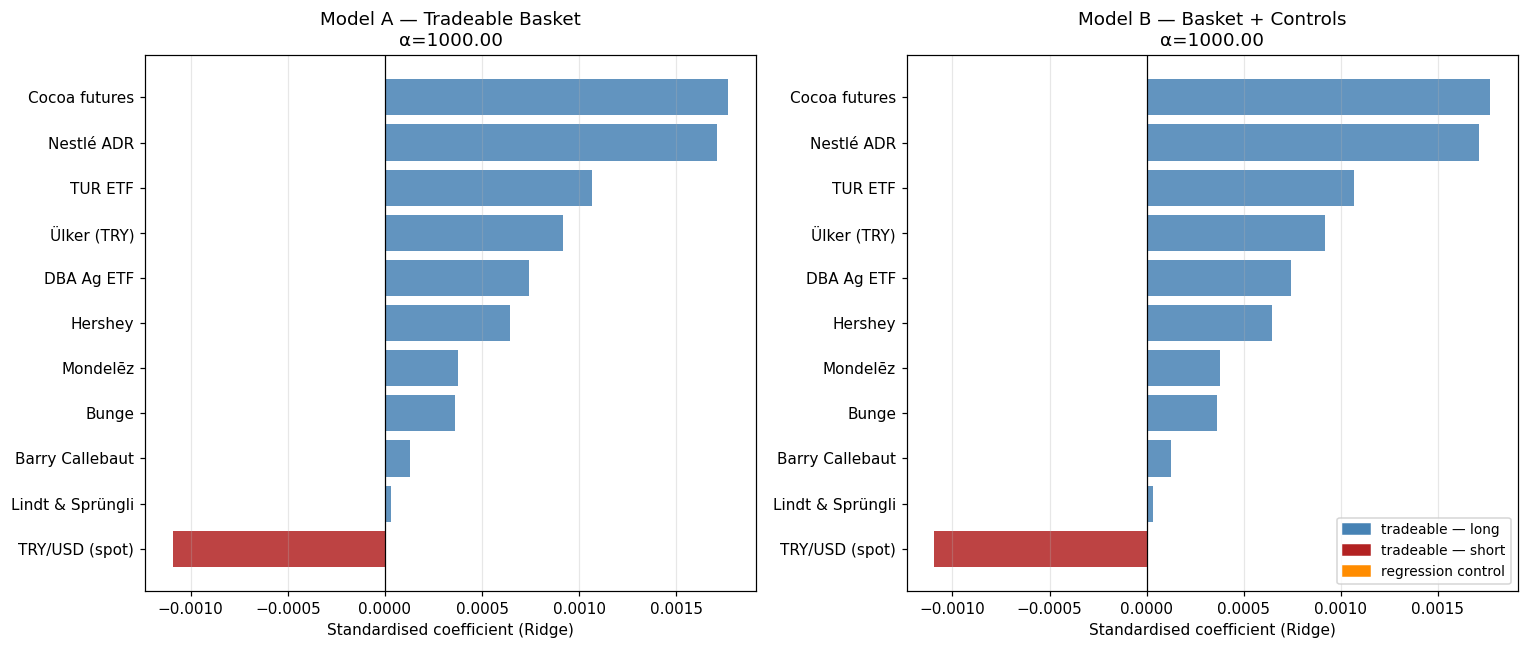

In [20]:
# ── Standardised weights — Model A (basket) and Model B (basket + controls) ───
from matplotlib.patches import Patch

_to_plot = [(m, f, t) for m, f, t in [
    (ridge_b, usable_basket, 'Model A — Tradeable Basket'),
    (ridge_f, usable_all,    'Model B — Basket + Controls'),
] if m is not None]

if not _to_plot:
    print('No models fitted.')
else:
    fig, axes = plt.subplots(1, len(_to_plot), figsize=(7 * len(_to_plot), 6))
    if len(_to_plot) == 1:
        axes = [axes]

    for ax, (model, features, title) in zip(axes, _to_plot):
        sorted_idx   = np.argsort(model.coef_)
        sorted_cols  = [features[i] for i in sorted_idx]
        sorted_coefs = model.coef_[sorted_idx]

        def _color(col, val):
            if col in CONTROL_COLS:
                return 'darkorange'
            return 'steelblue' if val >= 0 else 'firebrick'

        colors = [_color(c, v) for c, v in zip(sorted_cols, sorted_coefs)]
        ax.barh(range(len(sorted_cols)), sorted_coefs, color=colors, alpha=0.85)
        ax.set_yticks(range(len(sorted_cols)))
        ax.set_yticklabels([labels.get(c, c) for c in sorted_cols])
        ax.axvline(0, color='black', lw=0.8)
        ax.set_xlabel('Standardised coefficient (Ridge)')
        ax.set_title(f'{title}\nα={model.alpha_:.2f}')
        ax.grid(axis='x', alpha=0.3)

    axes[-1].legend(handles=[
        Patch(color='steelblue',  label='tradeable — long'),
        Patch(color='firebrick',  label='tradeable — short'),
        Patch(color='darkorange', label='regression control'),
    ], loc='lower right', fontsize=9)

    plt.tight_layout()
    plt.show()

In [21]:
# ── Save basket returns and weights ──────────────────────────────────────────
out = rets[ALL_FEATURES + ['haz_price_ret', 'haz_prod_ret']].copy()
out['basket_ret'] = basket_ret
out.to_csv(DATA / 'basket/basket_returns.csv')

if ridge_b is not None:
    w_basket = pd.DataFrame({
        'asset':    usable_basket,
        'label':    [labels.get(c, c) for c in usable_basket],
        'std_coef': ridge_b.coef_,
        'role':     'tradeable',
    })
    if ridge_f is not None and usable_controls:
        n_b = len(usable_basket)
        w_ctrl = pd.DataFrame({
            'asset':    usable_controls,
            'label':    [labels.get(c, c) for c in usable_controls],
            'std_coef': ridge_f.coef_[n_b:],
            'role':     'control',
        })
        weights_df = pd.concat([w_basket, w_ctrl], ignore_index=True)
    else:
        weights_df = w_basket

    weights_df = weights_df.sort_values('std_coef', ascending=False)
    weights_df.to_csv(DATA / 'basket/basket_weights.csv', index=False)
    print('Saved basket_returns.csv and basket_weights.csv')
    print(weights_df.to_string(index=False))
else:
    print('No model fitted — nothing saved.')

Saved basket_returns.csv and basket_weights.csv
      asset            label  std_coef      role
  cocoa_usd    Cocoa futures     0.002 tradeable
 nestle_usd       Nestlé ADR     0.002 tradeable
    tur_usd          TUR ETF     0.001 tradeable
  ulker_try      Ülker (TRY)     0.001 tradeable
    dba_usd       DBA Ag ETF     0.001 tradeable
hershey_usd          Hershey     0.001 tradeable
   mdlz_usd         Mondelēz     0.000 tradeable
  bunge_usd            Bunge     0.000 tradeable
  barry_chf  Barry Callebaut     0.000 tradeable
  lindt_chf Lindt & Sprüngli     0.000 tradeable
     tryusd   TRY/USD (spot)    -0.001 tradeable
